In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt

## Outliers

In [2]:
from scipy.stats import zscore
from ipywidgets import interact, FloatSlider

# Datos base
np.random.seed(42)
X = np.random.rand(50, 1) * 10
y = 2 * X + 1 + np.random.randn(50, 1) * 2

# Añadir outliers fijos
X_outliers = np.array([[2], [8]])
y_outliers = np.array([[40], [-30]])

X_todos = np.vstack((X, X_outliers))
y_todos = np.vstack((y, y_outliers))

# Gráfico interactivo: regresión con eliminación de outliers basada en Z-score
def graficar_regresion_filtrada(umbral_z=2.0):
    z_y = zscore(y_todos.flatten())
    mascara = np.abs(z_y) < umbral_z
    X_filtrado = X_todos[mascara]
    y_filtrado = y_todos[mascara]

    modelo_todos = LinearRegression().fit(X_todos, y_todos)
    modelo_filtrado = LinearRegression().fit(X_filtrado, y_filtrado)

    x_linea = np.linspace(0, 12, 100).reshape(-1, 1)
    y_pred_todos = modelo_todos.predict(x_linea)
    y_pred_filtrado = modelo_filtrado.predict(x_linea)

    plt.figure(figsize=(8, 5))
    plt.scatter(X_todos, y_todos, color='gray', label='Todos los datos')
    plt.scatter(X_todos[~mascara], y_todos[~mascara], color='red', label='Outliers detectados')
    plt.plot(x_linea, y_pred_todos, label='Con outliers', color='orange')
    plt.plot(x_linea, y_pred_filtrado, label='Sin outliers', linestyle='--', color='blue')
    plt.title(f'Umbral Z-score: {umbral_z:.1f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

# Widget interactivo
interact(graficar_regresion_filtrada,
         umbral_z=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.1))


interactive(children=(FloatSlider(value=2.0, description='umbral_z', max=5.0, min=0.5), Output()), _dom_classe…

<function __main__.graficar_regresion_filtrada(umbral_z=2.0)>

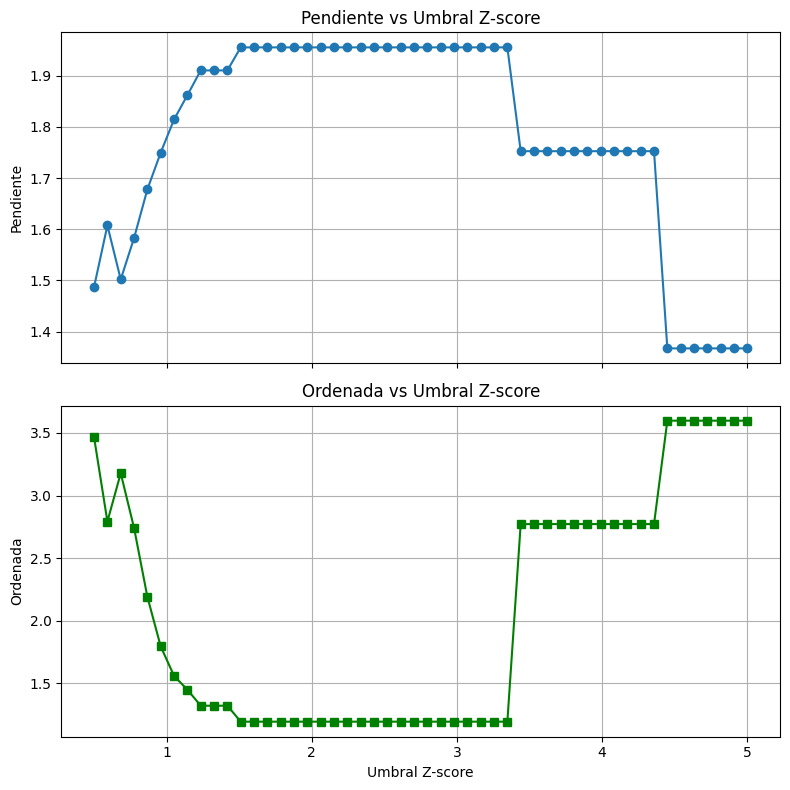

In [3]:
z_rango = np.linspace(0.5, 5.0, 50)
pendientes = []
ordenadas = []

for z_umbral in z_rango:
    z_y = zscore(y_todos.flatten())
    mascara = np.abs(z_y) < z_umbral
    X_filtrado = X_todos[mascara]
    y_filtrado = y_todos[mascara]
    modelo = LinearRegression().fit(X_filtrado, y_filtrado)
    pendientes.append(modelo.coef_[0][0])
    ordenadas.append(modelo.intercept_[0])

# Subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(z_rango, pendientes, marker='o')
axs[0].set_title('Pendiente vs Umbral Z-score')
axs[0].set_ylabel('Pendiente')
axs[0].grid(True)

axs[1].plot(z_rango, ordenadas, marker='s', color='green')
axs[1].set_title('Ordenada vs Umbral Z-score')
axs[1].set_xlabel('Umbral Z-score')
axs[1].set_ylabel('Ordenada')
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [4]:
pendientes = []
ordenadas = []
for i in range(100):
    random_indices = np.random.choice(len(X_todos), size=10, replace=False)
    X_ = X_todos[random_indices]
    y_ = y_todos[random_indices]
    modelo = LinearRegression().fit(X_, y_)
    pendientes.append(modelo.coef_[0][0])
    ordenadas.append(modelo.intercept_[0])

In [5]:
np.median(pendientes), np.median(ordenadas)

(np.float64(1.8139515055976598), np.float64(1.93662925035596))

In [6]:
from sklearn.linear_model import TheilSenRegressor

TheilSenRegressor().fit(X_todos, y_todos.ravel()).coef_

array([1.92667685])

## Valores faltantes

Vamos a trabajar con el dataset de [Air quality](https://archive.ics.uci.edu/dataset/360/air+quality)

In [7]:
df = pd.read_csv("AirQualityUCI.csv", sep=';', decimal=',')
df = df.iloc[:, :-2]
features = ['CO(GT)', 'C6H6(GT)', 'NO2(GT)', 'T']
df = df[features]
df.replace(-200, np.nan, inplace=True)  # Mark missing values
df = df[~df.isna().all(axis=1)]
df.shape, df.isna().sum()

((9326, 4),
 CO(GT)      1652
 C6H6(GT)     335
 NO2(GT)     1611
 T            335
 dtype: int64)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9326 entries, 0 to 9356
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CO(GT)    7674 non-null   float64
 1   C6H6(GT)  8991 non-null   float64
 2   NO2(GT)   7715 non-null   float64
 3   T         8991 non-null   float64
dtypes: float64(4)
memory usage: 364.3 KB


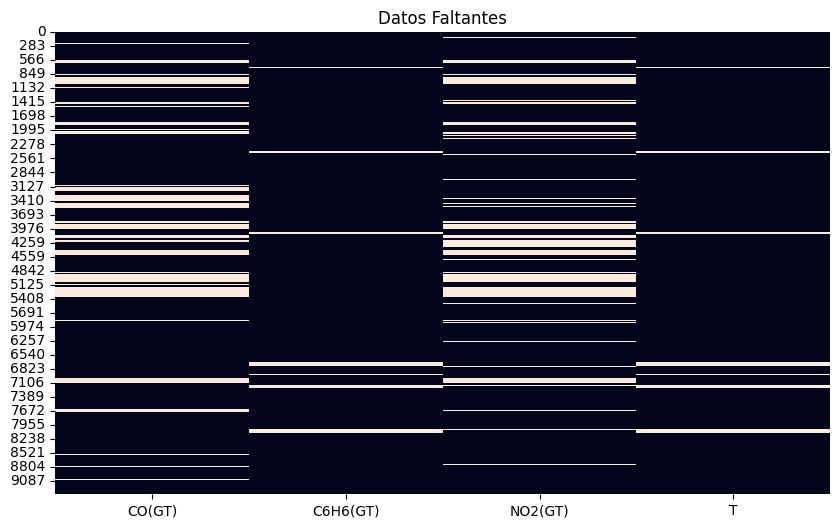

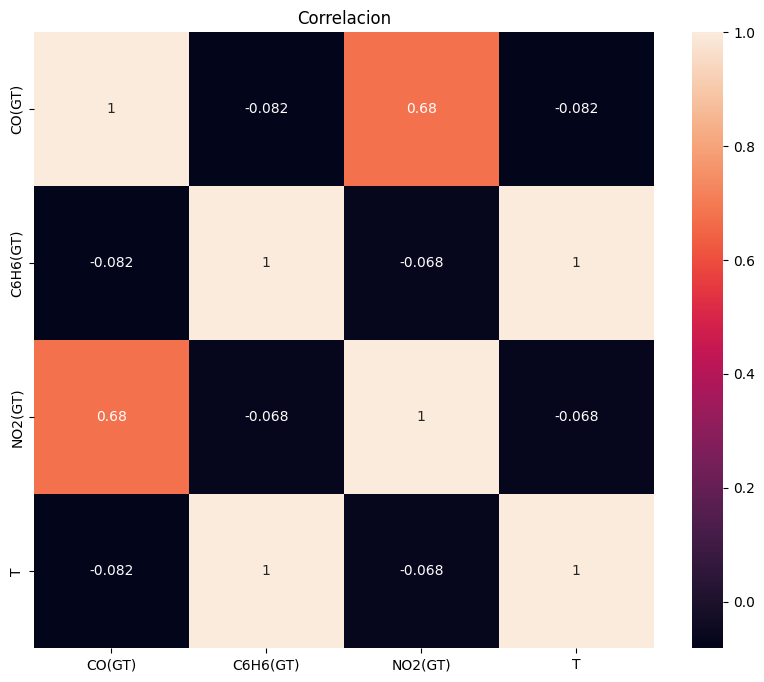

In [9]:
# Visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Datos Faltantes")
plt.show()

# Correlation of missingness
missing_indicators = df.isna().astype(int)
corr_missing = missing_indicators.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_missing, annot=True)
plt.title("Correlacion")
plt.show()

In [10]:
df['CO_missing'] = df['CO(GT)'].isna()
group_diff = df.groupby('CO_missing')['T'].mean()
group_diff

,T
CO_missing,
False,17.770425
True,20.758713


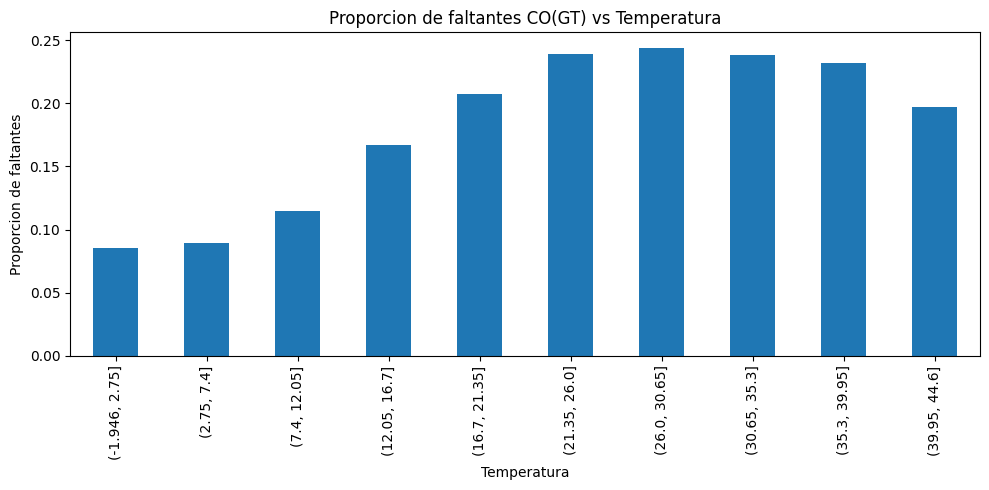

In [11]:
df_filtered = df[df['T'].notna()].copy()

# Bin temperature
df_filtered['T_bin'] = pd.cut(df_filtered['T'], bins=10)

# Proportion of missing CO(GT) per temp bin
missing_rate = df_filtered.groupby('T_bin', observed=False)['CO_missing'].mean()

# Plot
missing_rate.plot(kind='bar', figsize=(10, 5), title='Proporcion de faltantes CO(GT) vs Temperatura')
plt.ylabel('Proporcion de faltantes')
plt.xlabel('Temperatura')
plt.tight_layout()
plt.show()

In [12]:
df[df.isna().any(axis=1)]

,CO(GT),C6H6(GT),NO2(GT),T,CO_missing
9,0.6,1.7,NaN,10.3,False
10,NaN,1.3,34.0,10.1,True
33,0.8,1.9,NaN,7.0,False
34,NaN,1.1,32.0,6.1,True
39,NaN,22.1,NaN,9.2,True
...,...,...,...,...,...
9058,NaN,2.3,65.0,14.5,True
9130,NaN,6.0,92.0,16.2,True
9202,NaN,1.3,46.0,13.7,True
9274,NaN,0.8,41.0,13.7,True


## Imputacion

In [13]:
df.dropna(subset=['C6H6(GT)'], inplace=True)
# Separate target
X = df.drop(["C6H6(GT)", "CO_missing"], axis=1)
y = df["C6H6(GT)"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

In [14]:
X_train[X_train.isna().any(axis=1)]

,CO(GT),NO2(GT),T
298,NaN,31.0,10.1
1882,NaN,NaN,15.2
1867,NaN,NaN,27.5
1545,1.0,NaN,16.2
581,NaN,NaN,17.5
...,...,...,...
5262,NaN,NaN,14.1
3106,NaN,55.0,23.3
5290,NaN,NaN,16.0
1258,NaN,35.0,14.8


In [15]:
X_train['CO(GT)'].mean(), X_test['CO(GT)'].mean()

(np.float64(2.137410562180579), np.float64(2.0990502035278156))

## Regresión lineal múltiple + imputacion

In [16]:
# Column types
num_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
# cat_features = [""]

# Preprocessing pipeline
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean", add_indicator=True)),
    ("scaler", StandardScaler()),
    # ("imputer", KNNImputer(n_neighbors=5)),
])

# cat_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("encoder", OneHotEncoder(handle_unknown="ignore"))
# ])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    # ("cat", cat_pipe, cat_features)
])

# Final pipeline
model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

In [17]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CO(GT)', 'NO2(GT)',
                                                   'T'])])),
                ('regressor', LinearRegression())])

In [18]:
model.named_steps

{'preprocessing': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(add_indicator=True)),
                                                  ('scaler', StandardScaler())]),
                                  ['CO(GT)', 'NO2(GT)', 'T'])]),
 'regressor': LinearRegression()}

In [19]:
X_train.sample(10, random_state=0)

,CO(GT),NO2(GT),T
2416,1.6,98.0,29.3
3141,NaN,129.0,41.4
3436,1.8,85.0,28.6
1395,2.0,97.0,13.4
3780,0.4,27.0,22.7
899,NaN,NaN,12.8
6778,1.0,86.0,11.8
3345,NaN,NaN,23.6
4714,NaN,44.0,21.1
7578,2.6,151.0,13.9


In [20]:
pd.DataFrame(model.named_steps['preprocessing'].transform(X_train)).sample(10, random_state=0)

,0,1,2,3,4
7062,-0.415784,-0.332391,1.246608,-0.474566,-0.465747
4872,0.000000,0.385332,2.619858,2.107188,-0.465747
4034,-0.261048,-0.633371,1.167164,-0.474566,-0.465747
1281,-0.106312,-0.355543,-0.557910,-0.474566,-0.465747
5320,-1.344200,-1.976206,0.497563,-0.474566,-0.465747
5743,0.000000,0.000000,-0.626005,2.107188,2.147087
454,-0.879992,-0.610219,-0.739497,-0.474566,-0.465747
1014,0.000000,0.000000,0.599706,2.107188,2.147087
3457,0.000000,-1.582617,0.315976,2.107188,-0.465747
451,0.357896,0.894683,-0.501164,-0.474566,-0.465747


In [21]:
print('Pendiente: ', model['regressor'].coef_.round(1))
print('Intersección: ', model['regressor'].intercept_.round())

Pendiente:  [ 5.8  0.7  1.5 -0.8  0.2]
Intersección:  10.0


In [22]:
# Predecir y evaluar el modelo
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)
from sklearn.metrics import root_mean_squared_error, r2_score
print(f'Error cuadrático medio: {root_mean_squared_error(y_test, y_test_pred):.2f}')
print(f'Coeficiente de determinación: {r2_score(y_test, y_test_pred):.2f}')

Error cuadrático medio: 3.85
Coeficiente de determinación: 0.74


#### Gráficos

**Predicciones vs. Valores reales**

Text(0, 0.5, 'y_pred')

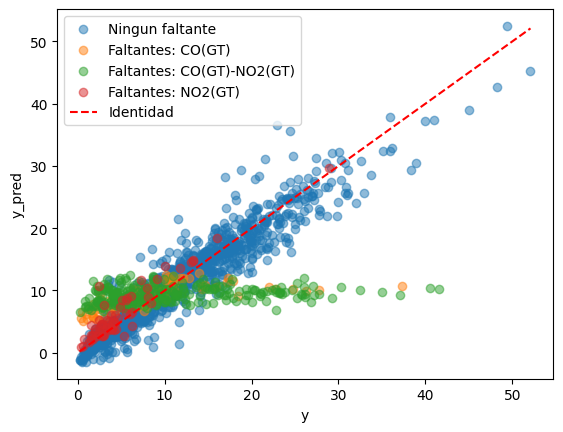

In [23]:
predictions = pd.DataFrame({'y_test': y_test, 'y_test_pred': y_test_pred})
x_color = X_test.copy()
x_color['null_columns'] = x_color.apply(
    lambda row: '-'.join([col for col in x_color.columns if pd.isnull(row[col])]),
    axis=1
)
x_color
for i, group in x_color.groupby('null_columns'):
    plt.scatter(predictions.loc[group.index, 'y_test'], predictions.loc[group.index, 'y_test_pred'], alpha=0.5, label=f'Faltantes: {i}' if i else 'Ningun faltante')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], ls='--', c='r', label='Identidad')
plt.legend()
plt.xlabel('y')
plt.ylabel('y_pred')